<a href="https://www.kaggle.com/code/aamir28/house-prices-regression-benchmark?scriptVersionId=321863353" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🏠 Regression Benchmark Notebook
### Kaggle | House Prices – Advanced Regression Techniques

This notebook provides a **full benchmark pipeline** including:
- EDA & visualizations
- Feature engineering & preprocessing
- Multiple model benchmarking (Ridge, Lasso, XGBoost, LightGBM)
- Cross-validation & RMSE comparison
- Stacking / blending ensemble
- Submission file generation

## 1. 📦 Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb

# Display settings
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

SEED = 42
N_FOLDS = 5
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. 📂 Load Data

In [2]:
# ── Kaggle path (competition data is at /kaggle/input/) ──────────────────────
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
train.head()

Train shape : (1460, 81)
Test  shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. 🔍 Exploratory Data Analysis

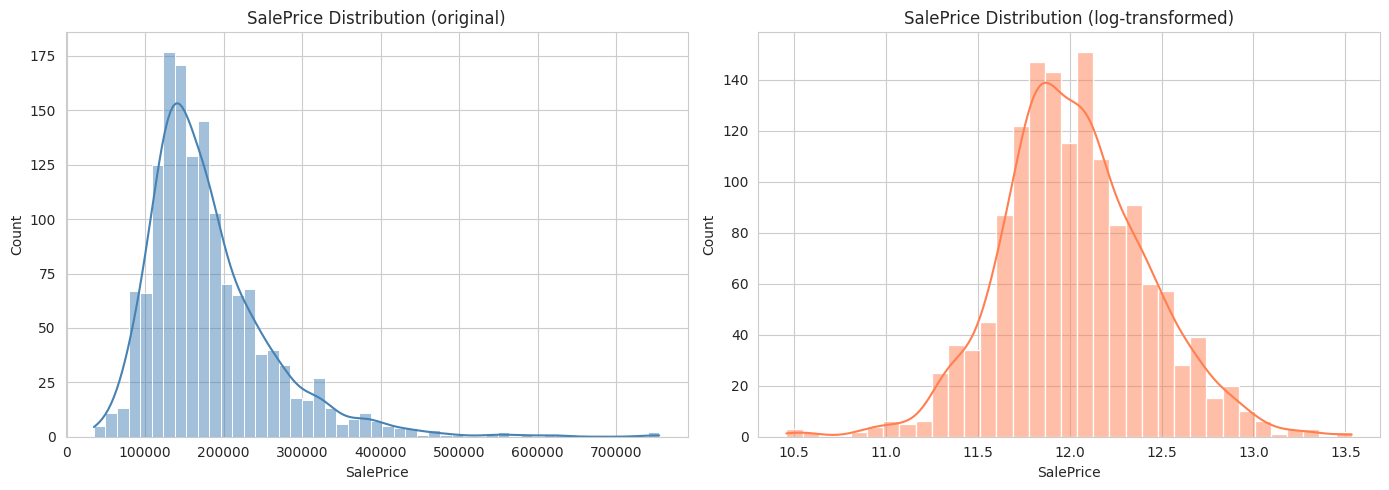

Skewness (original)   : 1.8829
Skewness (log1p)      : 0.1213


In [3]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice Distribution (original)')

sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('SalePrice Distribution (log-transformed)')

plt.tight_layout()
plt.show()

print(f"Skewness (original)   : {train['SalePrice'].skew():.4f}")
print(f"Skewness (log1p)      : {np.log1p(train['SalePrice']).skew():.4f}")

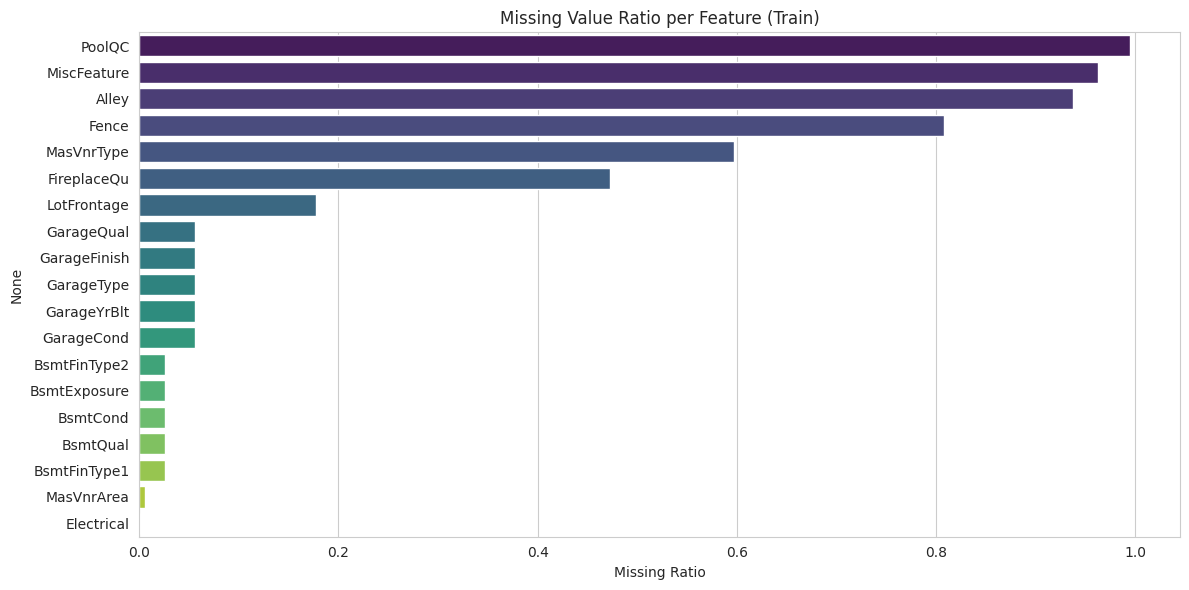

In [4]:
# Missing values heatmap
missing = train.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(12, 6))
sns.barplot(x=missing.values, y=missing.index, palette='viridis')
plt.title('Missing Value Ratio per Feature (Train)')
plt.xlabel('Missing Ratio')
plt.tight_layout()
plt.show()

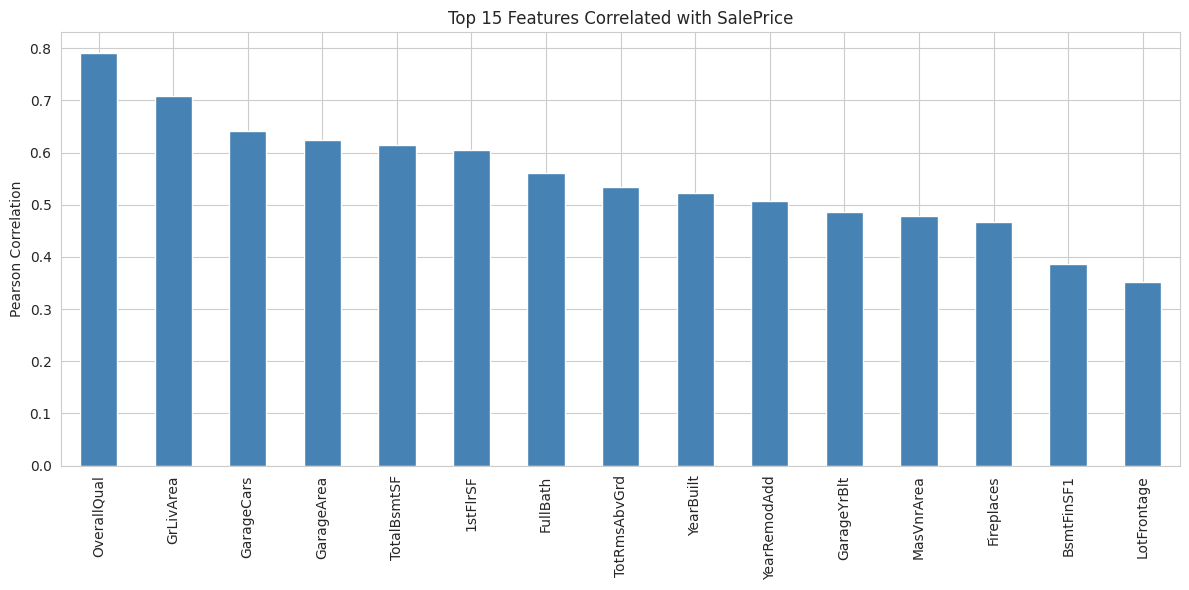

In [5]:
# Top correlations with SalePrice
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

plt.figure(figsize=(12, 6))
corr.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Features Correlated with SalePrice')
plt.ylabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## 4. 🛠️ Feature Engineering & Preprocessing

In [6]:
# Log-transform the target
y = np.log1p(train['SalePrice'])
train_id = train['Id']
test_id  = test['Id']

# Combine train + test for consistent preprocessing
all_data = pd.concat([train.drop(['Id', 'SalePrice'], axis=1),
                      test.drop(['Id'], axis=1)], axis=0).reset_index(drop=True)

print(f'Combined shape: {all_data.shape}')

Combined shape: (2919, 79)


In [7]:
# ── Fill NaN values ──────────────────────────────────────────────────────────

# Categorical: NaN often means 'None' (no feature)
cat_none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType', 'MSSubClass'
]
for col in cat_none_cols:
    if col in all_data.columns:
        all_data[col].fillna('None', inplace=True)

# Numeric: NaN means 0
num_zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_zero_cols:
    if col in all_data.columns:
        all_data[col].fillna(0, inplace=True)

# Fill remaining with mode (categorical) or median (numeric)
for col in all_data.columns:
    if all_data[col].isnull().sum() > 0:
        if all_data[col].dtype == 'object':
            all_data[col].fillna(all_data[col].mode()[0], inplace=True)
        else:
            all_data[col].fillna(all_data[col].median(), inplace=True)

print(f'Remaining NaN: {all_data.isnull().sum().sum()}')

Remaining NaN: 0


In [8]:
# ── Feature engineering ───────────────────────────────────────────────────────

all_data['TotalSF']        = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                               all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
all_data['TotalPorchSF']   = (all_data['OpenPorchSF'] + all_data['3SsnPorch'] +
                               all_data['EnclosedPorch'] + all_data['ScreenPorch'] +
                               all_data['WoodDeckSF'])
all_data['HouseAge']       = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge']       = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsNew']          = (all_data['YearBuilt'] == all_data['YrSold']).astype(int)
all_data['HasPool']        = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage']      = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt']        = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace']   = (all_data['Fireplaces'] > 0).astype(int)

print('✅ Feature engineering done. New shape:', all_data.shape)

✅ Feature engineering done. New shape: (2919, 89)


In [9]:
# ── Skewness correction on numeric features ────────────────────────────────
from scipy.stats import skew

num_feats = all_data.select_dtypes(include=[np.number]).columns
skewed    = all_data[num_feats].apply(skew).sort_values(ascending=False)
skewed    = skewed[abs(skewed) > 0.75].index

all_data[skewed] = np.log1p(all_data[skewed].clip(lower=0))
print(f'Log-transformed {len(skewed)} skewed numeric features')

Log-transformed 29 skewed numeric features


In [10]:
# ── Label encode & one-hot encode ─────────────────────────────────────────
all_data = pd.get_dummies(all_data)
print('Shape after one-hot encoding:', all_data.shape)

# Split back
n_train = len(train)
X_train = all_data.iloc[:n_train].values
X_test  = all_data.iloc[n_train:].values

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Shape after one-hot encoding: (2919, 312)
X_train: (1460, 312), X_test: (1459, 312)


## 5. 📊 Model Benchmarking

In [11]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def rmse_cv(model, X=X_train, y=y):
    scores = cross_val_score(model, X, y,
                             scoring='neg_root_mean_squared_error',
                             cv=kf)
    return -scores

results = {}

In [12]:
# ── Ridge ──────────────────────────────────────────────────────────────────
ridge = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  Ridge(alpha=10))
])
scores = rmse_cv(ridge)
results['Ridge'] = scores
print(f'Ridge      RMSE: {scores.mean():.4f} ± {scores.std():.4f}')

Ridge      RMSE: 0.1306 ± 0.0210


In [13]:
# ── Lasso ──────────────────────────────────────────────────────────────────
lasso = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  Lasso(alpha=0.0005, max_iter=10000))
])
scores = rmse_cv(lasso)
results['Lasso'] = scores
print(f'Lasso      RMSE: {scores.mean():.4f} ± {scores.std():.4f}')

Lasso      RMSE: 0.1258 ± 0.0217


In [14]:
# ── ElasticNet ─────────────────────────────────────────────────────────────
enet = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  ElasticNet(alpha=0.0005, l1_ratio=0.9, max_iter=10000))
])
scores = rmse_cv(enet)
results['ElasticNet'] = scores
print(f'ElasticNet RMSE: {scores.mean():.4f} ± {scores.std():.4f}')

ElasticNet RMSE: 0.1258 ± 0.0216


In [15]:
# ── XGBoost ────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=0,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.0006,
    random_state=SEED,
    tree_method='hist',
    n_jobs=-1
)
scores = rmse_cv(xgb_model)
results['XGBoost'] = scores
print(f'XGBoost    RMSE: {scores.mean():.4f} ± {scores.std():.4f}')

XGBoost    RMSE: 0.1265 ± 0.0175


In [16]:
# ── LightGBM ───────────────────────────────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=32,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.005,
    reg_lambda=0.005,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
scores = rmse_cv(lgb_model)
results['LightGBM'] = scores
print(f'LightGBM   RMSE: {scores.mean():.4f} ± {scores.std():.4f}')

LightGBM   RMSE: 0.1336 ± 0.0198


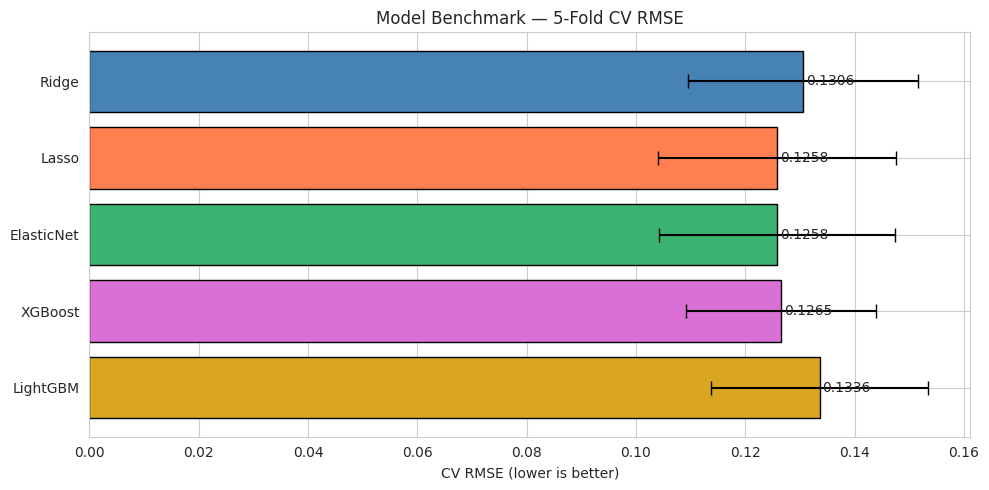

In [17]:
# ── Benchmark comparison plot ──────────────────────────────────────────────
means = {k: v.mean() for k, v in results.items()}
stds  = {k: v.std()  for k, v in results.items()}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod']
bars = ax.barh(list(means.keys()), list(means.values()),
               xerr=list(stds.values()), color=colors,
               edgecolor='black', capsize=5)

for bar, val in zip(bars, means.values()):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('CV RMSE (lower is better)')
ax.set_title('Model Benchmark — 5-Fold CV RMSE')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. 🤝 Ensemble — Stacking

In [18]:
# ── Weighted average blend (simple & effective) ────────────────────────────
# Weights inversely proportional to CV RMSE
inv = {k: 1/v for k, v in means.items()}
total = sum(inv.values())
weights = {k: v/total for k, v in inv.items()}
print('Blend weights:')
for k, w in weights.items():
    print(f'  {k:12s}: {w:.4f}')

Blend weights:
  Ridge       : 0.1967
  Lasso       : 0.2041
  ElasticNet  : 0.2041
  XGBoost     : 0.2029
  LightGBM    : 0.1922


In [19]:
estimators = [
    ('ridge', Pipeline([('scaler', RobustScaler()), ('model', Ridge(alpha=10))])),
    ('lasso', Pipeline([('scaler', RobustScaler()), ('model', Lasso(alpha=0.0005, max_iter=10000))])),
    ('xgb',   xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=3,
                                subsample=0.7, colsample_bytree=0.7,
                                random_state=SEED, tree_method='hist', n_jobs=-1)),
    ('lgb',   lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=32,
                                 subsample=0.8, colsample_bytree=0.8,
                                 random_state=SEED, n_jobs=-1, verbose=-1,
                                 feature_name='auto')),  
]

## 7. 🏆 Train Final Model & Generate Submission

In [20]:
# Train all base models on full training set
ridge.fit(X_train, y)
lasso.fit(X_train, y)
enet.fit(X_train, y)
xgb_model.fit(X_train, y)
lgb_model.fit(X_train, y)

print('✅ All models trained on full dataset')

✅ All models trained on full dataset


In [21]:
# Weighted blend predictions
preds = (
    weights['Ridge']      * ridge.predict(X_test) +
    weights['Lasso']      * lasso.predict(X_test) +
    weights['ElasticNet'] * enet.predict(X_test)  +
    weights['XGBoost']    * xgb_model.predict(X_test) +
    weights['LightGBM']   * lgb_model.predict(X_test)
)

# Inverse log transform
final_preds = np.expm1(preds)

submission = pd.DataFrame({'Id': test_id, 'SalePrice': final_preds})
submission.to_csv('submission.csv', index=False)
print('✅ submission.csv saved!')
submission.head(10)

✅ submission.csv saved!


,Id,SalePrice
0,1461,120574.421771
1,1462,158788.616156
2,1463,183359.563740
3,1464,196583.109262
4,1465,191037.544591
5,1466,171153.655363
6,1467,178516.324517
7,1468,164596.601895
8,1469,186002.949634
9,1470,122428.700498


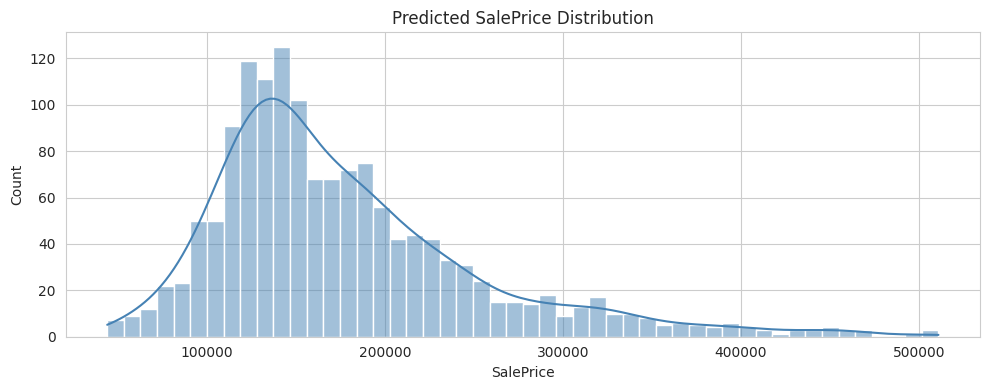

Min  : $44,194
Max  : $510,825
Mean : $177,923
Median: $156,893


In [22]:
# Prediction distribution sanity check
plt.figure(figsize=(10, 4))
sns.histplot(final_preds, kde=True, color='steelblue', bins=50)
plt.title('Predicted SalePrice Distribution')
plt.xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Min  : ${final_preds.min():,.0f}')
print(f'Max  : ${final_preds.max():,.0f}')
print(f'Mean : ${final_preds.mean():,.0f}')
print(f'Median: ${np.median(final_preds):,.0f}')

## 8. 🔑 Key Takeaways & Next Steps

| Step | What to try next |
|------|------------------|
| Feature Eng. | Add neighborhood-level aggregates, interaction terms |
| Outliers | Remove extreme GrLivArea outliers from training set |
| Hyperparams | Optuna / BayesSearchCV for XGB & LGB tuning |
| Ensemble | Add CatBoost or SVR to the stack |
| Validation | Use stratified splits on price quantiles |

Good luck! 🚀